In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [55]:
# Constants and parameters
DIRS = [(0, 1), (0, -1), (1, 0), (-1, 0)]
MAX_S = 500_000

In [56]:
# Helper functions and initialization of the grid
def init_g(n):
    g = np.zeros((n, n), dtype=np.int8)
    g[0, n//2]=1
    return g

In [57]:
# function to check if a particle is adjacent to the cluster
def n_clus(g, r, c):
    n = g.shape[0]
    for dr, dc in DIRS:
        nr, nc = r+dr, (c+dc)%n
        if 0 <= nr < n and g[nr, nc] == 1:
            return True
    return False

In [58]:
# Launch a particle from the top row
def launch_r(g):
    rows = np.where(g.any(axis=1))[0]
    return min(g.shape[0] - 1, rows.max() + 10)

### PART C

In [59]:
# function to perform a random walk for a particle until it sticks to the cluster or goes out of bounds
def walk_c(g):
    n = g.shape[0]
    lr = launch_r(g)
    r, c = lr, np.random.randint(0, n)
    
    # loop for random walk with a maximum number of steps to prevent infinite loops 
    for _ in range(MAX_S):
        dr, dc = DIRS[np.random.randint(4)]
        nr, nc = r+dr, (c+dc)%n
        # Checking if the new position is out of bounds
        if nr<0 or nr>=n:
            return False
        # Checking if the new position is already occupied by the cluster
        if g[nr, nc] == 1:
            continue

        r, c = nr, nc
        # Checking if the particle is adjacent to the cluster and stick with probability 1
        if n_clus(g, r, c):
            g[r, c]=1
            return True

    return False


In [60]:
# running the Monte Carlo DLA simulation for a given number of steps
def run_c(n, steps):
    g = init_g(n)
    grown = 0
    while grown<steps:
        if walk_c(g):
            grown += 1
    return g


In [61]:
# plotting function for the resulting cluster
def plot_clus(g, ax, title):
    cmap = ListedColormap(["white", "black"])
    ax.imshow(g, origin="lower", cmap=cmap, interpolation="nearest", extent=[0, 1, 0, 1])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

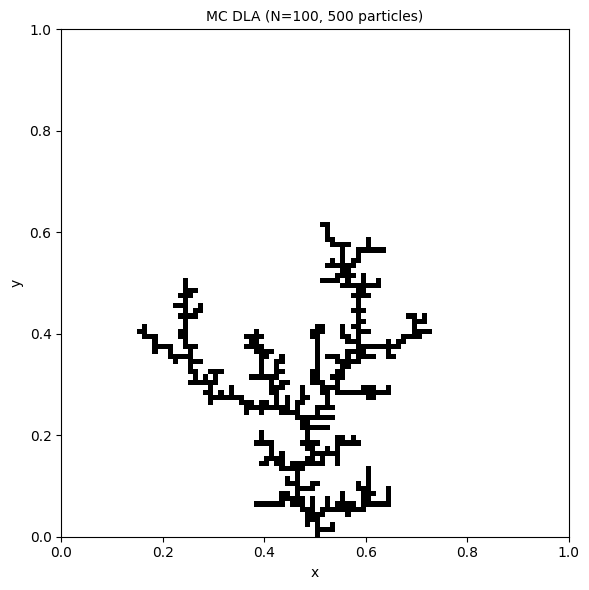

In [62]:
# Main execution
n = 100
steps = 500

g = run_c(n, steps)
fig, ax = plt.subplots(figsize=(6, 6))
plot_clus(g, ax, f"MC DLA (N={n}, {steps} particles)")
fig.tight_layout()
# fig.savefig("mc_dla_c.png", dpi=150)
plt.show()
plt.close()
# print("Saved mc_dla_c.png")

### PART D

In [63]:
# function to perform a random walk for a particle until it sticks to the cluster or goes out of bounds with a sticking probability ps
def walk_d(g, ps):
    n = g.shape[0]
    lr = launch_r(g)
    r, c = lr, np.random.randint(0, n)
    # loop for random walk with a maximum number of steps to prevent infinite loops
    for _ in range(MAX_S):
        dr, dc = DIRS[np.random.randint(4)]
        nr, nc = r+dr, (c+dc)%n
        # Checking if the new position is out of bounds
        if nr < 0 or nr >= n:
            return False
        # Checking if the new position is already occupied by the cluster
        if g[nr, nc] == 1:
            continue

        r, c = nr, nc
        # Checking if the particle is adjacent to the cluster and stick with probability ps
        if n_clus(g, r, c):
            if np.random.random() < ps:
                g[r, c] = 1
                return True

    return False

In [64]:
# running the Monte Carlo DLA simulation with sticking probability ps for a given number of steps
def run_d(n, steps, ps):
    g = init_g(n)
    grown = 0
    while grown<steps:
        if walk_d(g, ps):
            grown += 1
    return g


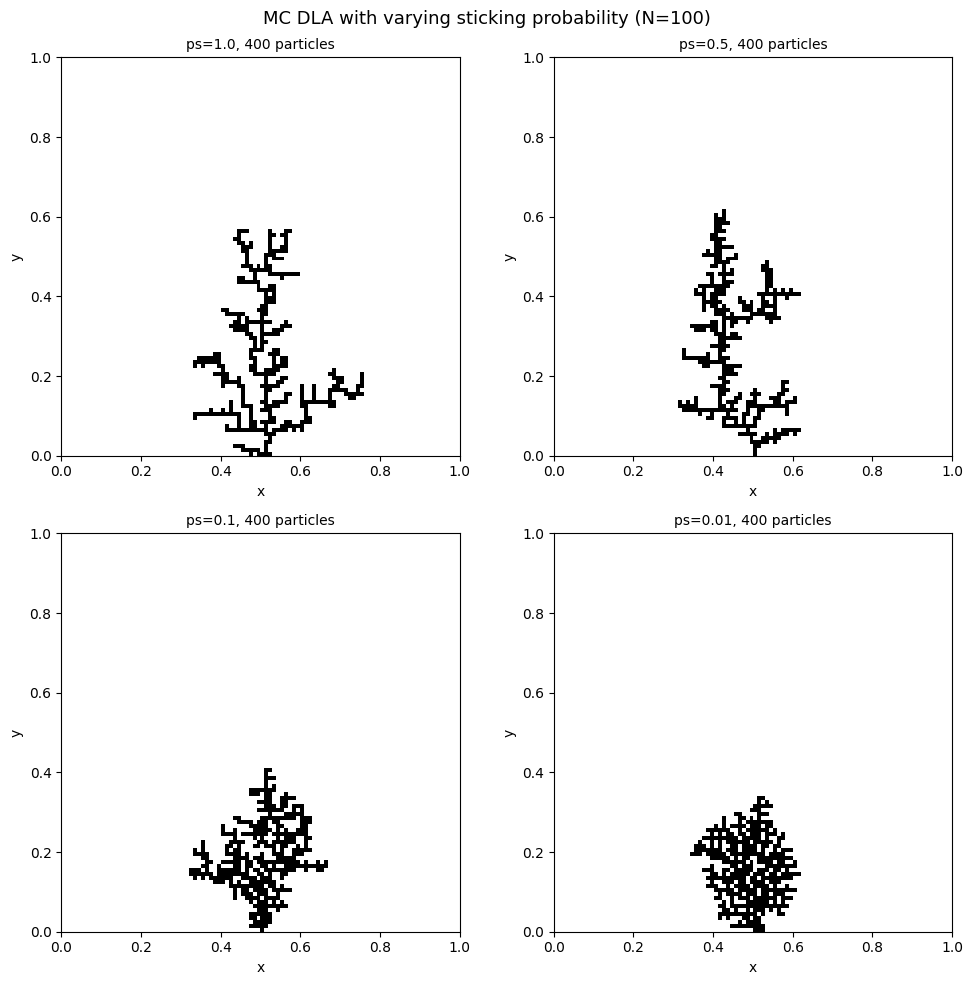

In [65]:
# Testing different sticking probabilities and plotting the resulting clusters
ps_vals = [1.0, 0.5, 0.1, 0.01]
steps_d = 400

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for i, ps in enumerate(ps_vals):
    g = run_d(n, steps_d, ps)
    plot_clus(g, axes[i], f"ps={ps}, {steps_d} particles")

fig.suptitle(f"MC DLA with varying sticking probability (N={n})", fontsize=13)
fig.tight_layout()
# fig.savefig("mc_dla_d.png", dpi=150)
plt.show()
plt.close()
# print("Saved mc_dla_d.png")